# UMAR Quantile Reproduction: ML Simulator Construction

This notebook constructs the cleaned 30-minute UMAR dataset, cross-fits the default emulator families, and writes the artifacts consumed by the inference notebook in this folder.

## Reader Guide

This notebook is intentionally specific about the modeling goal.

We are not trying to build a full building-physics simulator. We are building a short-horizon thermal-response emulator for one room:
- outcome of interest: the next 30-minute mean room temperature
- prediction inputs: only variables available at decision time
- scenario `psi`: a coarse operational context used for the paper-facing fidelity analysis
- profile/state information: current room temperature, lags, ambient conditions, and optional control context

The workflow is:
1. verify the UMAR files and inspect the schema
2. build a 30-minute causal table
3. remove the obvious high-temperature artifact windows that distorted variance-based inference
4. define `psi = h={hour}|w={is_weekend}|tq={temp_q}`
5. cross-fit several simple ML emulators
6. generate simulator-side samples with fixed per-scenario budget `k_j = 200`
7. save outputs for the inference notebook

## Experimental Design Used In This Folder

This self-contained folder fixes one concrete UMAR experiment so the paper-facing results are reproducible and easy to read.

Chosen setup:
- room temperature target: `temp_275`
- ambient temperature: `temp_amb`
- optional setpoint: `setp_275`
- optional irradiance: `irrad`
- resampling rule: `30min`
- window aggregation: mean
- target variable: next-step 30-minute mean room temperature `y_future`

Model families kept in the default comparison:
- `Linear Regression`
- `Decision Tree`
- `Multilayer Perceptron`

These are intentionally standard, readable ML simulators rather than highly tuned or physics-based building models.

Saved outputs in this reproduction repo are written under `umar_quantile/output/`, while archived figures are written under `umar_quantile/figures/`.

In [1]:
from pathlib import Path
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd

PROJECT_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / 'data/umar/raw').exists() and (candidate / 'data/umar/metadata/umar_metadata.csv').exists() and (candidate / 'umar_quantile').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate the paper_reproduction root.')

UMAR_DIR = PROJECT_ROOT / 'umar_quantile'
if str(UMAR_DIR) not in sys.path:
    sys.path.insert(0, str(UMAR_DIR))

warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

DATA_DIR = PROJECT_ROOT / 'data' / 'umar' / 'raw'
META_PATH = PROJECT_ROOT / 'data' / 'umar' / 'metadata' / 'umar_metadata.csv'
UMAR_CSVS = sorted(DATA_DIR.glob('*.csv'))
OUTPUT_DIR = PROJECT_ROOT / 'umar_quantile' / 'output'
FIGURE_DIR = PROJECT_ROOT / 'umar_quantile' / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

# Make matplotlib use a writable cache dir later when it is imported.
MPLCONFIGDIR = Path('/tmp/mplconfig_umar_repro')
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

try:
    import pyarrow  # noqa: F401
    HAVE_PYARROW = True
except Exception:
    HAVE_PYARROW = False

print('PROJECT_ROOT =', Path('.'))
print('pyarrow available:', HAVE_PYARROW)
print('MPLCONFIGDIR =', os.environ.get('MPLCONFIGDIR'))

PROJECT_ROOT = .
pyarrow available: True
MPLCONFIGDIR = /tmp/mplconfig_umar_repro


## File Checks And Schema Preview

This reproduction notebook expects the UMAR raw files to live inside `data/umar/` within the reproduction repo, not in an external workspace path.

In [2]:
from IPython.display import display

print('UMAR CSV files found:')
for path in UMAR_CSVS:
    print(' -', path.relative_to(PROJECT_ROOT))
print('metadata exists:', META_PATH.exists())
if not UMAR_CSVS or not META_PATH.exists():
    raise FileNotFoundError('Missing UMAR raw files or metadata file.')

preview_path = UMAR_CSVS[0]
preview_df = pd.read_csv(preview_path, nrows=5)
metadata_df = pd.read_csv(META_PATH)

print()
print('first CSV:', preview_path.name)
print('number of columns:', preview_df.shape[1])
print('first 60 columns:')
print(preview_df.columns[:60].tolist())
display(preview_df.head())

print()
print('metadata columns:', metadata_df.columns.tolist())
display(metadata_df.head())

UMAR CSV files found:
 - data/umar/raw/umar_2019-07-01_2020-07-01_wide_descId.csv
 - data/umar/raw/umar_2020-07-01_2021-07-01_wide_descId.csv
 - data/umar/raw/umar_2021-07-01_2022-07-01_wide_descId.csv
 - data/umar/raw/umar_2022-07-01_2023-07-01_wide_descId.csv
metadata exists: True

first CSV: umar_2019-07-01_2020-07-01_wide_descId.csv
number of columns: 30
first 60 columns:
['Unnamed: 0', 'time', 'cooling_power', 'dhw_power', 'dhw_volume', 'heating_power', 'irrad', 'setp_272', 'setp_273', 'setp_274', 'setp_275', 'setp_276', 'temp_272', 'temp_273', 'temp_274', 'temp_275', 'temp_276', 'temp_amb', 'total_active_power', 'window_272', 'window_273_1', 'window_273_2', 'window_274', 'y1_272', 'y1_273', 'y1_274', 'y1_275', 'y1_276', 'y2_273', 'y3_273']


,Unnamed: 0,time,cooling_power,dhw_power,dhw_volume,heating_power,irrad,setp_272,setp_273,setp_274,setp_275,setp_276,temp_272,temp_273,temp_274,temp_275,temp_276,temp_amb,total_active_power,window_272,window_273_1,window_273_2,window_274,y1_272,y1_273,y1_274,y1_275,y1_276,y2_273,y3_273
0,1,2019-07-01 00:00:00,0.524,0.0,NaN,0.001,0.0,16.0,23.0,16.0,26.0,26.0,23.7795,23.7795,23.3071,24.0,NaN,25.9,0.35091,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
1,2,2019-07-01 00:01:00,0.509,0.0,0.000,0.001,0.0,16.0,23.0,16.0,26.0,26.0,23.7795,23.7795,23.3071,24.0,NaN,25.9,0.34398,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
2,3,2019-07-01 00:02:00,1.950,0.0,0.000,0.001,0.0,16.0,23.0,16.0,26.0,26.0,23.7795,23.7795,23.3071,24.0,NaN,25.8,0.35847,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
3,4,2019-07-01 00:03:00,2.087,0.0,0.001,0.001,0.0,16.0,23.0,16.0,26.0,26.0,23.7795,23.7795,23.3071,24.0,NaN,25.8,0.35721,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
4,5,2019-07-01 00:04:00,2.081,0.0,0.001,0.001,0.0,16.0,23.0,16.0,26.0,26.0,23.7795,23.7795,23.3071,24.0,NaN,25.9,0.32571,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0



metadata columns: ['NumericID', ' DescriptiveID     ', ' Description                                      ', ' Unit ', ' Type']


,NumericID,DescriptiveID,Description,Unit,Type
0,Index,Index,Index ...,Index,Index
1,3200000,temp_amb,Ambient temperature [�C] ...,roof,Temperature Ambient
2,3200008,irrad,Global solar irradiation [W/m^2] ...,roof,Solar Radiation
3,42150270,y1_272,Valve position room 272 [0/1] ...,umar,Valve
4,42150271,y1_273,Valve 1 position room 273 [0/1] ...,umar,Valve


## Fixed Run Configuration

The original exploratory notebook allowed manual column confirmation. For the cleaned reproducible run used in this folder, we now lock the columns and model settings so the end-to-end workflow is deterministic.

In [3]:
TIME_COL = 'time'
TARGET_TEMP_COL = 'temp_275'
AMBIENT_TEMP_COL = 'temp_amb'
OPTIONAL_SETPOINT_COL = 'setp_275'
OPTIONAL_IRRAD_COL = 'irrad'

RESAMPLE_RULE = '30min'
WINDOW_AGG = 'mean'
K_PER_SCENARIO = 200
N_FOLDS = 5
RANDOM_SEED = 7
ARTIFACT_TEMP_THRESHOLD_C = 30.0

selected_cols = [TIME_COL, TARGET_TEMP_COL, AMBIENT_TEMP_COL, OPTIONAL_SETPOINT_COL, OPTIONAL_IRRAD_COL]
selected_cols = [c for c in selected_cols if c is not None]

config_preview = pd.DataFrame(
    {
        'setting': [
            'TIME_COL', 'TARGET_TEMP_COL', 'AMBIENT_TEMP_COL', 'OPTIONAL_SETPOINT_COL', 'OPTIONAL_IRRAD_COL',
            'RESAMPLE_RULE', 'WINDOW_AGG', 'K_PER_SCENARIO', 'N_FOLDS', 'RANDOM_SEED', 'ARTIFACT_TEMP_THRESHOLD_C'
        ],
        'value': [
            TIME_COL, TARGET_TEMP_COL, AMBIENT_TEMP_COL, OPTIONAL_SETPOINT_COL, OPTIONAL_IRRAD_COL,
            RESAMPLE_RULE, WINDOW_AGG, K_PER_SCENARIO, N_FOLDS, RANDOM_SEED, ARTIFACT_TEMP_THRESHOLD_C
        ]
    }
)
display(config_preview)

,setting,value
0,TIME_COL,time
1,TARGET_TEMP_COL,temp_275
2,AMBIENT_TEMP_COL,temp_amb
3,OPTIONAL_SETPOINT_COL,setp_275
4,OPTIONAL_IRRAD_COL,irrad
5,RESAMPLE_RULE,30min
6,WINDOW_AGG,mean
7,K_PER_SCENARIO,200
8,N_FOLDS,5
9,RANDOM_SEED,7


## Build The 30-Minute Causal Table

The causal table uses information available at or before time `t` to predict the next 30-minute room-temperature window.

Construction logic:
- aggregate the raw UMAR time series to 30-minute windows
- define `room_temp_t` as the current 30-minute room-temperature window
- define `y_future` as the next 30-minute room-temperature window
- create calendar features and lags from the current state only
- define `temp_q` as the ambient-temperature quartile used in the scenario label

Default scenario definition:
- `psi = h={hour}|w={is_weekend}|tq={temp_q}`

In [4]:
frames = []
for path in UMAR_CSVS:
    df = pd.read_csv(path, usecols=lambda c: c in selected_cols)
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')
    df = df.dropna(subset=[TIME_COL]).copy()
    frames.append(df)

raw_df = pd.concat(frames, ignore_index=True)
raw_df = raw_df.sort_values(TIME_COL).reset_index(drop=True)

agg_map = {
    TARGET_TEMP_COL: WINDOW_AGG,
    AMBIENT_TEMP_COL: 'mean',
    OPTIONAL_SETPOINT_COL: 'mean',
    OPTIONAL_IRRAD_COL: 'mean',
}
agg_map = {k: v for k, v in agg_map.items() if k is not None}

resampled_df = (
    raw_df.set_index(TIME_COL)
    .resample(RESAMPLE_RULE)
    .agg(agg_map)
    .reset_index()
    .rename(columns={TIME_COL: 'timestamp'})
)
resampled_df['room_temp_t'] = resampled_df[TARGET_TEMP_COL]
resampled_df['ambient_temp'] = resampled_df[AMBIENT_TEMP_COL]
if OPTIONAL_SETPOINT_COL is not None:
    resampled_df['setpoint_t'] = resampled_df[OPTIONAL_SETPOINT_COL]
if OPTIONAL_IRRAD_COL is not None:
    resampled_df['irrad_t'] = resampled_df[OPTIONAL_IRRAD_COL]

resampled_df['y_future'] = resampled_df['room_temp_t'].shift(-1)
resampled_df['lag1'] = resampled_df['room_temp_t']
resampled_df['lag2'] = resampled_df['room_temp_t'].shift(1)
resampled_df['hour'] = resampled_df['timestamp'].dt.hour
resampled_df['weekday'] = resampled_df['timestamp'].dt.weekday
resampled_df['is_weekend'] = (resampled_df['weekday'] >= 5).astype(int)
resampled_df['month'] = resampled_df['timestamp'].dt.month
resampled_df['year'] = resampled_df['timestamp'].dt.year
resampled_df['temp_q'] = pd.qcut(resampled_df['ambient_temp'], q=4, labels=False, duplicates='drop')
resampled_df['temp_q'] = resampled_df['temp_q'].astype('Int64')

causal_df = resampled_df.dropna(subset=['room_temp_t', 'ambient_temp', 'lag1', 'lag2', 'y_future', 'temp_q']).copy()
causal_df['temp_q'] = causal_df['temp_q'].astype(int)
causal_df['psi'] = causal_df.apply(lambda r: f"h={int(r['hour'])}|w={int(r['is_weekend'])}|tq={int(r['temp_q'])}", axis=1)
causal_df = causal_df.reset_index(drop=True)
causal_df['row_id'] = np.arange(len(causal_df), dtype=int)

print('causal rows before cleaning:', len(causal_df))
print('timestamp range:', causal_df['timestamp'].min(), 'to', causal_df['timestamp'].max())
print('number of scenarios m before cleaning:', causal_df['psi'].nunique())
display(causal_df[['timestamp', 'room_temp_t', 'ambient_temp', 'lag1', 'lag2', 'y_future', 'psi']].head())

causal rows before cleaning: 67611
timestamp range: 2019-07-01 00:30:00 to 2023-06-30 23:00:00
number of scenarios m before cleaning: 192


,timestamp,room_temp_t,ambient_temp,lag1,lag2,y_future,psi
0,2019-07-01 00:30:00,24.0,25.353333,24.0,24.0,24.0,h=0|w=0|tq=3
1,2019-07-01 01:00:00,24.0,24.933333,24.0,24.0,24.0,h=1|w=0|tq=3
2,2019-07-01 01:30:00,24.0,25.253333,24.0,24.0,24.0,h=1|w=0|tq=3
3,2019-07-01 02:00:00,24.0,24.646667,24.0,24.0,24.0,h=2|w=0|tq=3
4,2019-07-01 02:30:00,24.0,24.640000,24.0,24.0,24.0,h=2|w=0|tq=3


## First-Pass Artifact Cleaning

The earlier variance-based analysis was dominated by a tiny number of extreme 30-minute temperature windows. For the main paper-facing run, we remove rows when any of the following exceed `30C`:
- current room temperature `room_temp_t`
- lagged state `lag1`
- lagged state `lag2`
- future target `y_future`

This is not meant to be a universal cleaning rule. It is a transparent artifact filter used because those rare windows were driving unstable variance tails that were not representative of the bulk building behavior.

In [5]:
trim_cols = ['room_temp_t', 'lag1', 'lag2', 'y_future']
trim_mask = (causal_df[trim_cols] <= ARTIFACT_TEMP_THRESHOLD_C).all(axis=1)
removed_df = causal_df.loc[~trim_mask, ['timestamp', 'psi', 'room_temp_t', 'lag1', 'lag2', 'y_future']].copy()
clean_df = causal_df.loc[trim_mask].copy().reset_index(drop=True)
clean_df['row_id'] = np.arange(len(clean_df), dtype=int)

scenario_sizes = clean_df.groupby('psi').size().rename('n_j').reset_index().sort_values('n_j', ascending=False)

print('artifact threshold (C):', ARTIFACT_TEMP_THRESHOLD_C)
print('rows removed:', len(removed_df))
print('share removed:', f"{len(removed_df) / len(causal_df):.4%}")
print('scenarios touched:', removed_df['psi'].nunique())
print('number of scenarios m after cleaning:', clean_df['psi'].nunique())
if len(removed_df):
    print()
    print('example removed rows:')
    display(removed_df.head(12))
print()
print('scenario-size summary after cleaning:')
display(scenario_sizes['n_j'].describe().to_frame().T)
display(scenario_sizes.head(12))

artifact threshold (C): 30.0
rows removed: 56
share removed: 0.0828%
scenarios touched: 32
number of scenarios m after cleaning: 192

example removed rows:


,timestamp,psi,room_temp_t,lag1,lag2,y_future
5507,2019-10-27 01:30:00,h=1|w=1|tq=1,22.880000,22.880000,22.880000,45.920000
5508,2019-10-27 02:00:00,h=2|w=1|tq=3,45.920000,45.920000,22.880000,45.973333
5509,2019-10-27 02:30:00,h=2|w=1|tq=2,45.973333,45.973333,45.920000,23.040000
5510,2019-10-27 03:00:00,h=3|w=1|tq=1,23.040000,23.040000,45.973333,23.040000
21806,2020-10-15 11:30:00,h=11|w=0|tq=1,21.879300,21.879300,21.742800,41.270370
21807,2020-10-15 12:00:00,h=12|w=0|tq=2,41.270370,41.270370,21.879300,43.023600
21808,2020-10-15 12:30:00,h=12|w=0|tq=2,43.023600,43.023600,41.270370,29.270310
21809,2020-10-15 13:00:00,h=13|w=0|tq=1,29.270310,29.270310,43.023600,21.307050
21811,2020-10-15 15:30:00,h=15|w=0|tq=2,41.543280,41.543280,21.417300,43.480350
21812,2020-10-15 16:00:00,h=16|w=0|tq=2,43.480350,43.480350,41.543280,43.763850



scenario-size summary after cleaning:


,count,mean,std,min,25%,50%,75%,max
n_j,192.0,351.848958,193.014399,38.0,197.75,291.5,497.75,844.0


,psi,n_j
51,h=15|w=0|tq=3,844
43,h=14|w=0|tq=3,843
59,h=16|w=0|tq=3,827
35,h=13|w=0|tq=3,821
27,h=12|w=0|tq=3,773
67,h=17|w=0|tq=3,771
160,h=6|w=0|tq=0,729
152,h=5|w=0|tq=0,722
19,h=11|w=0|tq=3,706
75,h=18|w=0|tq=3,705


## Cross-Fitted Emulator Construction

Feature set used by all emulators:
- `room_temp_t`
- `lag1`
- `lag2`
- `hour`
- `is_weekend`
- `month`
- `ambient_temp`
- `setpoint_t`
- `irrad_t`

Cross-fitting design:
- split the cleaned 30-minute table into `N_FOLDS = 5` contiguous time blocks
- fit each emulator on the other four folds
- predict only on the held-out fold
- store out-of-fold real rows and emulator predictions

This keeps the evaluation out-of-sample without discarding a large terminal block.

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score
from umar_utils import add_model_annotations, make_default_emulators, rmse_score

feature_cols = ['room_temp_t', 'lag1', 'lag2', 'hour', 'is_weekend', 'month', 'ambient_temp']
if OPTIONAL_SETPOINT_COL is not None:
    feature_cols.append('setpoint_t')
if OPTIONAL_IRRAD_COL is not None:
    feature_cols.append('irrad_t')

clean_df = clean_df.dropna(subset=feature_cols).copy().reset_index(drop=True)
clean_df['row_id'] = np.arange(len(clean_df), dtype=int)
print('rows after dropping missing feature values:', len(clean_df))

fold_id = np.empty(len(clean_df), dtype=int)
for fold_num, idx in enumerate(np.array_split(np.arange(len(clean_df)), N_FOLDS)):
    fold_id[idx] = fold_num
clean_df['fold_id'] = fold_id

fold_ranges = clean_df.groupby('fold_id').agg(start_timestamp=('timestamp', 'min'), end_timestamp=('timestamp', 'max'), rows=('row_id', 'size')).reset_index()
display(fold_ranges)

fitted_models = {}
oof_prediction_rows = []
fold_metric_rows = []
for fold_num in range(N_FOLDS):
    train_df = clean_df[clean_df['fold_id'] != fold_num].copy()
    test_df = clean_df[clean_df['fold_id'] == fold_num].copy()
    X_train = train_df[feature_cols].to_numpy(dtype=float)
    y_train = train_df['y_future'].to_numpy(dtype=float)
    X_test = test_df[feature_cols].to_numpy(dtype=float)
    y_test = test_df['y_future'].to_numpy(dtype=float)

    emulators = make_default_emulators(random_state=RANDOM_SEED + fold_num)
    for model_name, emulator in emulators.items():
        emulator.fit(X_train, y_train)
        fitted_models[(model_name, fold_num)] = emulator
        y_pred = emulator.predict_mean(X_test)
        fold_metric_rows.append({
            'fold_id': fold_num,
            'model_name': model_name,
            'rmse': rmse_score(y_test, y_pred),
            'mae': float(mean_absolute_error(y_test, y_pred)),
            'r2': float(r2_score(y_test, y_pred)),
            'train_rows': int(len(train_df)),
            'test_rows': int(len(test_df)),
        })
        block = test_df[['row_id', 'fold_id', 'timestamp', 'psi', 'y_future']].copy()
        block['model_name'] = model_name
        block['y_real'] = block['y_future']
        block['y_pred_mean'] = y_pred
        block = block.drop(columns=['y_future'])
        oof_prediction_rows.append(block)

fold_summary_df = add_model_annotations(pd.DataFrame(fold_metric_rows)).sort_values(['model_display_name', 'fold_id']).reset_index(drop=True)
oof_pred_df = add_model_annotations(pd.concat(oof_prediction_rows, ignore_index=True))
oof_real_df = clean_df[['row_id', 'fold_id', 'timestamp', 'psi', 'y_future']].rename(columns={'y_future': 'y_real'}).copy()
model_catalog_df = add_model_annotations(pd.DataFrame({'model_name': sorted(make_default_emulators(random_state=RANDOM_SEED).keys())}))[
    ['model_name', 'model_display_name', 'literature_family', 'paper_alignment_note']
]

display(model_catalog_df)
display(fold_summary_df)

rows after dropping missing feature values: 66922


,fold_id,start_timestamp,end_timestamp,rows
0,0,2019-07-01 00:30:00,2020-04-20 14:30:00,13385
1,1,2020-04-20 15:00:00,2021-02-04 01:30:00,13385
2,2,2021-02-04 02:00:00,2021-11-17 14:30:00,13384
3,3,2021-11-17 15:00:00,2022-09-23 06:30:00,13384
4,4,2022-09-23 07:00:00,2023-06-30 23:00:00,13384


,model_name,model_display_name,literature_family,paper_alignment_note
0,DecisionTree,Decision Tree,Decision-tree family,Included as a deliberately shallow decision-tr...
1,LinearModel,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...
2,MLP,Multilayer Perceptron,Artificial neural network family,Used here as a standard multilayer perceptron ...


,fold_id,model_name,rmse,mae,r2,train_rows,test_rows,model_display_name,literature_family,paper_alignment_note
0,0,DecisionTree,0.214829,0.176089,0.930962,53537,13385,Decision Tree,Decision-tree family,Included as a deliberately shallow decision-tr...
1,1,DecisionTree,0.227309,0.169494,0.886819,53537,13385,Decision Tree,Decision-tree family,Included as a deliberately shallow decision-tr...
2,2,DecisionTree,0.269108,0.198142,0.947242,53538,13384,Decision Tree,Decision-tree family,Included as a deliberately shallow decision-tr...
3,3,DecisionTree,0.550359,0.319248,0.874734,53538,13384,Decision Tree,Decision-tree family,Included as a deliberately shallow decision-tr...
4,4,DecisionTree,0.642122,0.367054,0.767282,53538,13384,Decision Tree,Decision-tree family,Included as a deliberately shallow decision-tr...
5,0,LinearModel,0.099375,0.054029,0.985227,53537,13385,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...
6,1,LinearModel,0.152575,0.064339,0.949007,53537,13385,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...
7,2,LinearModel,0.123308,0.065472,0.988923,53538,13384,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...
8,3,LinearModel,0.134373,0.070512,0.992533,53538,13384,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...
9,4,LinearModel,0.187936,0.094240,0.980065,53538,13384,Linear Regression,Linear-regression baseline,Plain linear regression on the causal feature ...


## Simulator-Side Sampling And Saved Outputs

For each emulator and each scenario `psi`, we sample a fixed number of held-out profile states and generate `k_j = 200` simulator-side draws. This gives a balanced simulator budget across scenarios for the downstream fidelity analysis.

Saved outputs written by this notebook:
- `umar_quantile/output/umar_30min.parquet`
- `umar_quantile/output/umar_oof_real.parquet`
- `umar_quantile/output/umar_oof_q_samples.parquet`
- `umar_quantile/output/umar_oof_predictions.csv`
- `umar_quantile/output/umar_counts.csv`
- `umar_quantile/output/umar_fold_summary.csv`
- `umar_quantile/output/umar_simulator_config.json`
- `umar_quantile/figures/umar_simulator_rmse.png`

In [7]:
rng = np.random.default_rng(RANDOM_SEED)
q_sample_rows = []
for model_name in sorted(oof_pred_df['model_name'].unique()):
    model_pool = oof_pred_df[oof_pred_df['model_name'] == model_name].copy()
    for psi_value, psi_pool in model_pool.groupby('psi', sort=True):
        sampled_positions = rng.choice(psi_pool.index.to_numpy(), size=K_PER_SCENARIO, replace=True)
        sampled_pool = psi_pool.loc[sampled_positions].copy().reset_index(drop=True)
        for fold_num, fold_group in sampled_pool.groupby('fold_id', sort=False):
            emulator = fitted_models[(model_name, int(fold_num))]
            row_ids = fold_group['row_id'].to_numpy(dtype=int)
            X_group = clean_df.loc[row_ids, feature_cols].to_numpy(dtype=float)
            y_draws = emulator.sample_y(X_group, rng=rng)
            out = fold_group[['row_id', 'fold_id', 'timestamp', 'psi']].copy()
            out['model_name'] = model_name
            out['y_sim'] = y_draws
            q_sample_rows.append(out)
q_samples_df = add_model_annotations(pd.concat(q_sample_rows, ignore_index=True))

counts_df = (
    q_samples_df.groupby(['model_name', 'psi']).size().rename('k_j').reset_index()
    .merge(oof_real_df.groupby('psi').size().rename('n_j').reset_index(), on='psi', how='left')
)
counts_df['gamma_j'] = counts_df['n_j'].apply(lambda n: float(1.0 - n ** (-1.0 / 3.0)))
counts_df = add_model_annotations(counts_df)

support_min = float(clean_df['y_future'].min())
support_max = float(clean_df['y_future'].max())
scale_bounds_c = (float(np.floor(support_min) - 0.5), float(np.ceil(support_max) + 0.5))
config = {
    'TIME_COL': TIME_COL,
    'TARGET_TEMP_COL': TARGET_TEMP_COL,
    'AMBIENT_TEMP_COL': AMBIENT_TEMP_COL,
    'OPTIONAL_SETPOINT_COL': OPTIONAL_SETPOINT_COL,
    'OPTIONAL_IRRAD_COL': OPTIONAL_IRRAD_COL,
    'feature_cols': feature_cols,
    'RESAMPLE_RULE': RESAMPLE_RULE,
    'WINDOW_AGG': WINDOW_AGG,
    'K_PER_SCENARIO': K_PER_SCENARIO,
    'N_FOLDS': N_FOLDS,
    'RANDOM_SEED': RANDOM_SEED,
    'artifact_temp_threshold_c': ARTIFACT_TEMP_THRESHOLD_C,
    'rows_removed_by_artifact_filter': int(len(removed_df)),
    'raw_y_support_c': [support_min, support_max],
    'scaled_reference_bounds_c': list(scale_bounds_c),
    'model_catalog': model_catalog_df.to_dict(orient='records'),
}

if not HAVE_PYARROW:
    raise ImportError('pyarrow is required for the simulator notebook outputs.')

clean_df.to_parquet(OUTPUT_DIR / 'umar_30min.parquet', index=False)
oof_real_df.to_parquet(OUTPUT_DIR / 'umar_oof_real.parquet', index=False)
q_samples_df.to_parquet(OUTPUT_DIR / 'umar_oof_q_samples.parquet', index=False)
oof_pred_df.to_csv(OUTPUT_DIR / 'umar_oof_predictions.csv', index=False)
fold_summary_df.to_csv(OUTPUT_DIR / 'umar_fold_summary.csv', index=False)
counts_df.to_csv(OUTPUT_DIR / 'umar_counts.csv', index=False)
(OUTPUT_DIR / 'umar_simulator_config.json').write_text(json.dumps(config, indent=2))

print('saved core simulator outputs')
for p in [
    OUTPUT_DIR / 'umar_30min.parquet',
    OUTPUT_DIR / 'umar_oof_real.parquet',
    OUTPUT_DIR / 'umar_oof_q_samples.parquet',
    OUTPUT_DIR / 'umar_oof_predictions.csv',
    OUTPUT_DIR / 'umar_counts.csv',
    OUTPUT_DIR / 'umar_fold_summary.csv',
    OUTPUT_DIR / 'umar_simulator_config.json',
]:
    print(' -', p.relative_to(PROJECT_ROOT))

saved core simulator outputs
 - umar_quantile/output/umar_30min.parquet
 - umar_quantile/output/umar_oof_real.parquet
 - umar_quantile/output/umar_oof_q_samples.parquet
 - umar_quantile/output/umar_oof_predictions.csv
 - umar_quantile/output/umar_counts.csv
 - umar_quantile/output/umar_fold_summary.csv
 - umar_quantile/output/umar_simulator_config.json


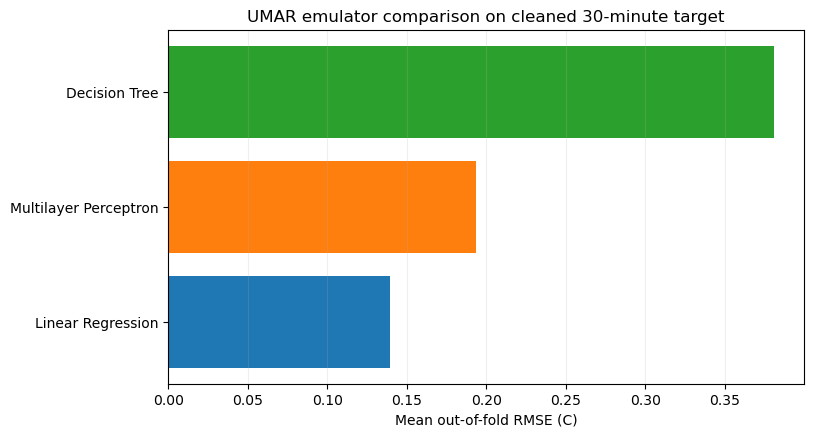

In [8]:
import matplotlib.pyplot as plt

rmse_plot_df = fold_summary_df.groupby('model_display_name', as_index=False)['rmse'].mean().sort_values('rmse')
colors = plt.get_cmap('tab10').colors[: len(rmse_plot_df)]
fig_height = max(4.6, 0.58 * len(rmse_plot_df) + 1.2)
fig, ax = plt.subplots(figsize=(8.2, fig_height))
ax.barh(rmse_plot_df['model_display_name'], rmse_plot_df['rmse'], color=colors)
ax.set_xlabel('Mean out-of-fold RMSE (C)')
ax.set_title('UMAR emulator comparison on cleaned 30-minute target')
ax.grid(axis='x', alpha=0.2)
fig.savefig(FIGURE_DIR / 'umar_simulator_rmse.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## Handoff To The Inference Notebook

The next notebook in this folder, `umar_quantile_inference.ipynb`, reads the artifacts saved under `umar_quantile/output/` and reproduces the main variance-based quantile figure.